# 06. Error Analysis

## Цель
Провести детальный анализ ошибок лучшей модели классификации бухгалтерских документов.

## Выбранная модель
В качестве основной модели используется:
- `SGDClassifier`
- `loss="hinge"`
- расширенный текстовый признак с использованием `Supplier_Name`

## Задачи
1. Обучить выбранную лучшую модель на training-части выборки.
2. Получить предсказания на test-части.
3. Построить confusion matrix.
4. Выделить наиболее частые ошибки классификации.
5. Проанализировать ошибочные объекты на уровне исходных признаков.
6. Сформулировать причины ошибок и ограничения модели.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.linear_model import SGDClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 300)

In [7]:
X_train_best = sparse.load_npz("../data/modified/X_train_best_model.npz")
X_test_best = sparse.load_npz("../data/modified/X_test_best_model.npz")
y_train = pd.read_csv("../data/modified/y_train_best_model.csv").squeeze("columns")
y_test = pd.read_csv("../data/modified/y_test_best_model.csv").squeeze("columns")
train_best_readable = pd.read_csv("../data/modified/train_best_model_readable.csv")
test_best_readable = pd.read_csv("../data/modified/test_best_model_readable.csv")

In [6]:
best_model = SGDClassifier(
    loss="hinge",
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)
best_model.fit(X_train_best, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",2000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [8]:
y_pred = best_model.predict(X_test_best)

In [9]:
metrics_df = pd.DataFrame({
    "metric": ["accuracy", "macro_f1", "weighted_f1"],
    "value": [
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test, y_pred, average="weighted")
    ]
})
display(metrics_df)

,metric,value
0,accuracy,0.901961
1,macro_f1,0.824359
2,weighted_f1,0.905229


In [10]:
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
display(report_df)

,precision,recall,f1-score,support
1000001,1.000000,1.000000,1.000000,6.000000
1001002,0.000000,0.000000,0.000000,0.000000
1001004,0.000000,0.000000,0.000000,2.000000
4000006,1.000000,0.500000,0.666667,2.000000
4000010,1.000000,1.000000,1.000000,6.000000
4000012,1.000000,1.000000,1.000000,3.000000
4000013,0.000000,0.000000,0.000000,0.000000
4000015,1.000000,1.000000,1.000000,2.000000
4000017,1.000000,1.000000,1.000000,1.000000
4000021,0.333333,1.000000,0.500000,1.000000


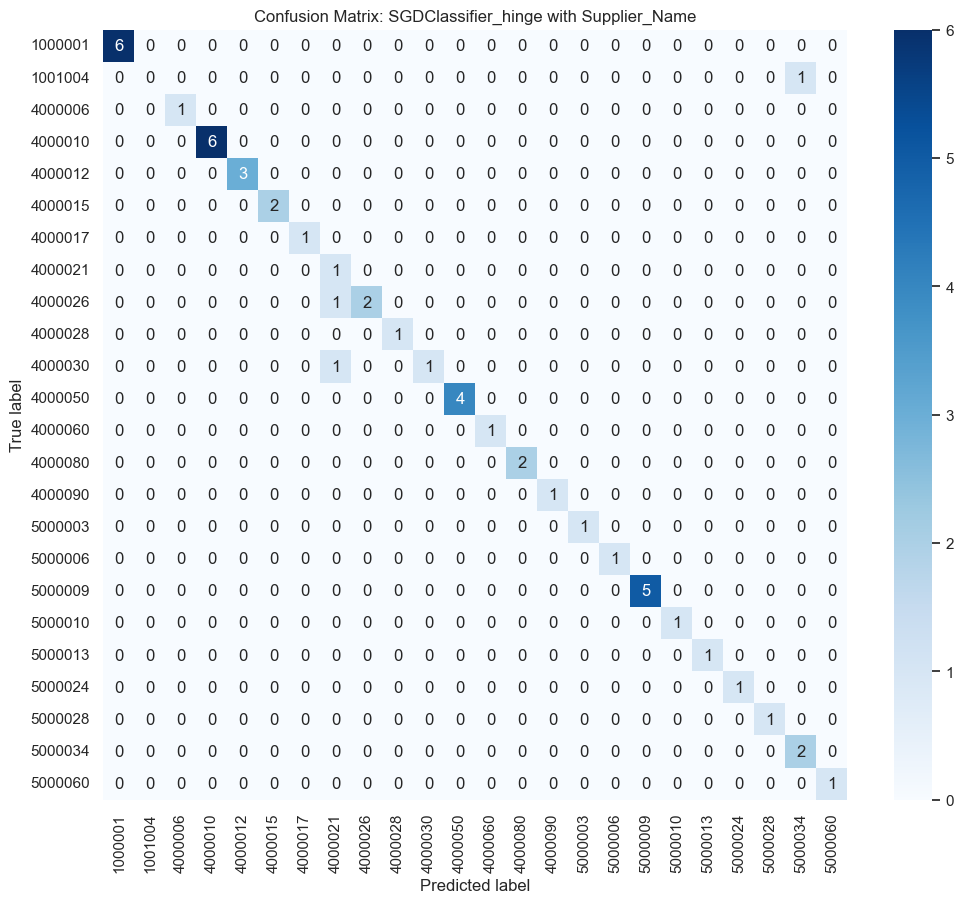

In [12]:
labels_in_test = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_in_test)
cm_df = pd.DataFrame(cm, index=labels_in_test, columns=labels_in_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: SGDClassifier_hinge with Supplier_Name")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [13]:
per_class_metrics = (
    report_df.loc[
        [idx for idx in report_df.index if str(idx).isdigit()],
        ["precision", "recall", "f1-score", "support"]
    ]
    .sort_values("f1-score", ascending=False)
)
display(per_class_metrics)

,precision,recall,f1-score,support
1000001,1.000000,1.000000,1.000000,6.0
4000012,1.000000,1.000000,1.000000,3.0
4000017,1.000000,1.000000,1.000000,1.0
4000010,1.000000,1.000000,1.000000,6.0
4000015,1.000000,1.000000,1.000000,2.0
4000090,1.000000,1.000000,1.000000,1.0
4000060,1.000000,1.000000,1.000000,1.0
4000080,1.000000,1.000000,1.000000,2.0
4000050,1.000000,1.000000,1.000000,4.0
4000028,1.000000,1.000000,1.000000,1.0


In [15]:
error_analysis_df = test_best_readable.copy()
error_analysis_df["y_true"] = y_test.values
error_analysis_df["y_pred"] = y_pred
error_analysis_df["is_correct"] = (error_analysis_df["y_true"] == error_analysis_df["y_pred"]).astype(int)
display(error_analysis_df.head())

,Dataset,Date,Invoice,Supplier_Code,Supplier_Name,Invoice_Item,Item_Description,Item_Value,Item_Quantity,Total_Amount,Taxes_Credit_%,Taxes_Credit_Amount,Total_Net_Amount,Account_Number,Account_Description,Activity_Code,Activity_Description,Year,Month,Day,Item_Description_Length,Item_Description_Word_Count,Has_Tax_Credit,Combined_Text,y_true,y_pred,is_correct
0,Test,2024-01-01,4500,10001,abs & abc tax consulting,1,review of federal tax obligations,2500,1,2500,0,0.0,2500.0,4000010,Audit and Consulting,7020400,"business management consulting, except specialized technical consulting",2024,1,1,33,5,0,"review of federal tax obligations business management consulting, except specialized technical consulting abs & abc tax consulting",4000010,4000010,1
1,Test,2024-01-01,4551,10001,abs & abc tax consulting,1,tax credits review from 2019 to 2023,10000,1,10000,0,0.0,10000.0,4000010,Audit and Consulting,7020400,"business management consulting, except specialized technical consulting",2024,1,1,36,7,0,"tax credits review from 2019 to 2023 business management consulting, except specialized technical consulting abs & abc tax consulting",4000010,4000010,1
2,Test,2024-01-01,2100,10002,hju travel agency,1,assistance with flight and hotel arrangements,1500,1,1500,0,0.0,1500.0,4000080,Other Third-Party Services,7911200,travel agencies,2024,1,1,45,6,0,assistance with flight and hotel arrangements travel agencies hju travel agency,4000080,4000080,1
3,Test,2024-01-01,1350,10003,abc associated lawyers,1,legal advisory in tax lawsuit,10000,1,10000,0,0.0,10000.0,4000012,Legal Services,6911701,legal services,2024,1,1,29,5,0,legal advisory in tax lawsuit legal services abc associated lawyers,4000012,4000012,1
4,Test,2024-01-01,1390,10003,abc associated lawyers,1,legal advisory in labor lawsuit,5000,1,5000,0,0.0,5000.0,4000012,Legal Services,6911701,legal services,2024,1,1,31,5,0,legal advisory in labor lawsuit legal services abc associated lawyers,4000012,4000012,1


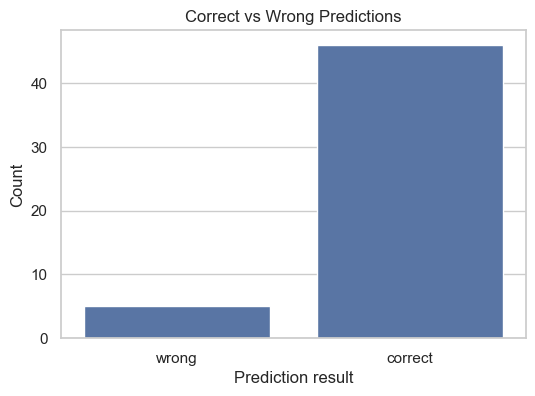

,is_correct,count,label
0,0,5,wrong
1,1,46,correct


In [16]:
correctness_counts = error_analysis_df["is_correct"].value_counts().sort_index().reset_index()
correctness_counts.columns = ["is_correct", "count"]
correctness_counts["label"] = correctness_counts["is_correct"].map({0: "wrong", 1: "correct"})
plt.figure(figsize=(6, 4))
sns.barplot(data=correctness_counts, x="label", y="count")
plt.title("Correct vs Wrong Predictions")
plt.xlabel("Prediction result")
plt.ylabel("Count")
plt.show()
display(correctness_counts)

In [17]:
misclassified_df = error_analysis_df[error_analysis_df["is_correct"] == 0].copy()
display(misclassified_df.head(20))

,Dataset,Date,Invoice,Supplier_Code,Supplier_Name,Invoice_Item,Item_Description,Item_Value,Item_Quantity,Total_Amount,Taxes_Credit_%,Taxes_Credit_Amount,Total_Net_Amount,Account_Number,Account_Description,Activity_Code,Activity_Description,Year,Month,Day,Item_Description_Length,Item_Description_Word_Count,Has_Tax_Credit,Combined_Text,y_true,y_pred,is_correct
17,Test,2024-01-01,1395,10009,qbz datatech,1,bi training,3200,1,3200,0,0.0,3200.0,4000030,Training,6204000,it consulting,2024,1,1,11,2,0,bi training it consulting qbz datatech,4000030,4000021,0
21,Test,2024-01-01,822,10011,saz industrial machinery,1,tool fvg,4500,1,4500,20,900.0,3600.0,1001004,Industrial Tools,4789005,retail trade of household cleaning products,2024,1,1,8,2,1,tool fvg retail trade of household cleaning products saz industrial machinery,1001004,1001002,0
35,Test,2024-01-01,1860,10016,yfc textile products,2,corporate uniforms,130,8,1040,0,0.0,1040.0,4000026,Uniforms,6822600,real estate property management and administration,2024,1,1,18,2,0,corporate uniforms real estate property management and administration yfc textile products,4000026,4000021,0
39,Test,2024-01-01,793,10018,csf wholesale and retail,1,cleaning products (kit),50,10,500,0,0.0,500.0,4000006,Consumables,4613300,"commercial representatives and agents of wood, construction materials, and hardware",2024,1,1,23,3,0,"cleaning products (kit) commercial representatives and agents of wood, construction materials, and hardware csf wholesale and retail",4000006,4000013,0
46,Test,2024-01-01,650,10023,mhg industrial tools,2,tool asr,4300,1,4300,20,860.0,3440.0,1001004,Industrial Tools,4612500,"commercial representatives and agents of fuels, minerals, steel, and chemical products",2024,1,1,8,2,1,"tool asr commercial representatives and agents of fuels, minerals, steel, and chemical products mhg industrial tools",1001004,5000034,0


In [22]:
supplier_error_df = (
    error_analysis_df.groupby("Supplier_Name")
    .agg(
        total_rows=("Supplier_Name", "size"),
        errors=("is_correct", lambda x: (x == 0).sum())
    )
    .reset_index()
)
supplier_error_df["error_rate"] = supplier_error_df["errors"] / supplier_error_df["total_rows"]
supplier_error_df = supplier_error_df.sort_values(["error_rate", "errors"], ascending=[False, False])

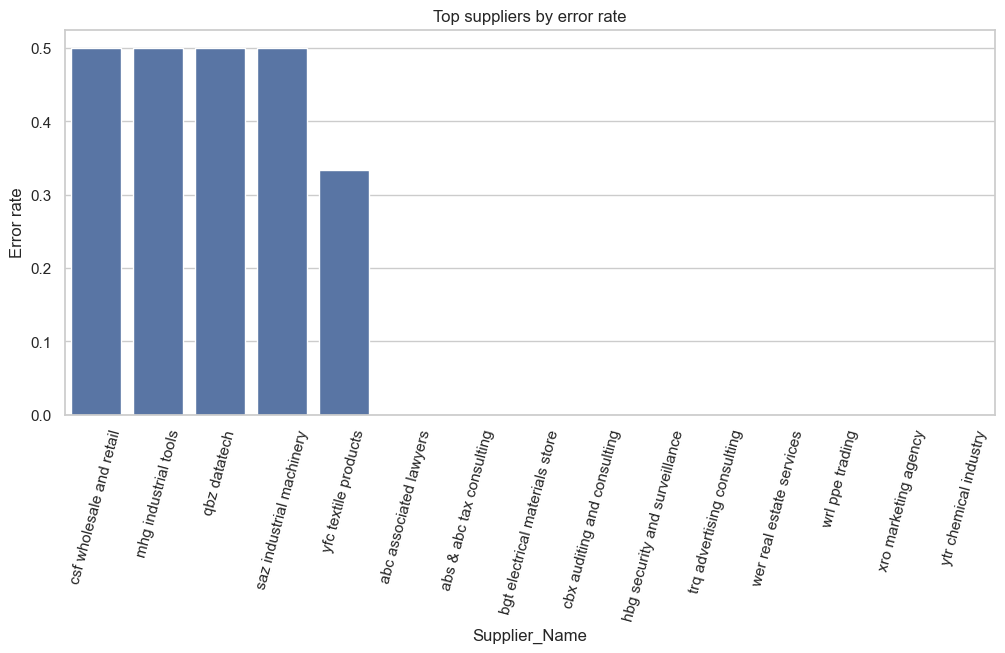

,Supplier_Name,total_rows,errors,error_rate
8,csf wholesale and retail,2,1,0.500000
13,mhg industrial tools,2,1,0.500000
17,qbz datatech,2,1,0.500000
20,saz industrial machinery,2,1,0.500000
25,yfc textile products,3,1,0.333333
0,abc associated lawyers,3,0,0.000000
1,abs & abc tax consulting,2,0,0.000000
4,bgt electrical materials store,5,0,0.000000
6,cbx auditing and consulting,2,0,0.000000
9,hbg security and surveillance,2,0,0.000000


In [23]:
top_supplier_errors = supplier_error_df[supplier_error_df["total_rows"] >= 2].head(15)
plt.figure(figsize=(12, 5))
sns.barplot(data=top_supplier_errors, x="Supplier_Name", y="error_rate")
plt.title("Top suppliers by error rate")
plt.xlabel("Supplier_Name")
plt.ylabel("Error rate")
plt.xticks(rotation=75)
plt.show()
display(top_supplier_errors)

In [25]:
activity_error_df = (
    error_analysis_df.groupby("Activity_Description")
    .agg(
        total_rows=("Activity_Description", "size"),
        errors=("is_correct", lambda x: (x == 0).sum())
    )
    .reset_index()
)
activity_error_df["error_rate"] = activity_error_df["errors"] / activity_error_df["total_rows"]
activity_error_df = activity_error_df.sort_values(["error_rate", "errors"], ascending=[False, False])
display(activity_error_df.head(20))

,Activity_Description,total_rows,errors,error_rate
5,"commercial representatives and agents of fuels, minerals, steel, and chemical products",2,1,0.500000
7,"commercial representatives and agents of wood, construction materials, and hardware",2,1,0.500000
17,retail trade of household cleaning products,2,1,0.500000
9,it consulting,3,1,0.333333
13,real estate property management and administration,3,1,0.333333
0,actuarial auditing and consulting,2,0,0.000000
1,advertising agencies,1,0,0.000000
2,advertising consulting,1,0,0.000000
3,building and residential cleaning,1,0,0.000000
4,"business management consulting, except specialized technical consulting",8,0,0.000000


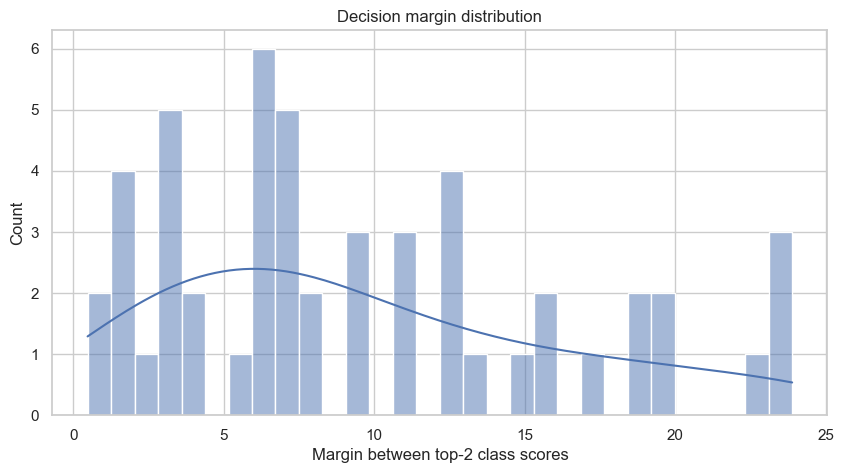

,count,mean,std,min,25%,50%,75%,max
decision_margin,51.0,9.592749,6.618315,0.479399,4.067403,7.466489,13.048797,23.889418


In [28]:
decision_scores = best_model.decision_function(X_test_best)
sorted_scores = np.sort(decision_scores, axis=1)
margin = sorted_scores[:, -1] - sorted_scores[:, -2]
error_analysis_df["decision_margin"] = margin
plt.figure(figsize=(10, 5))
sns.histplot(error_analysis_df["decision_margin"], bins=30, kde=True)
plt.title("Decision margin distribution")
plt.xlabel("Margin between top-2 class scores")
plt.ylabel("Count")
plt.show()
display(error_analysis_df["decision_margin"].describe().to_frame().T)

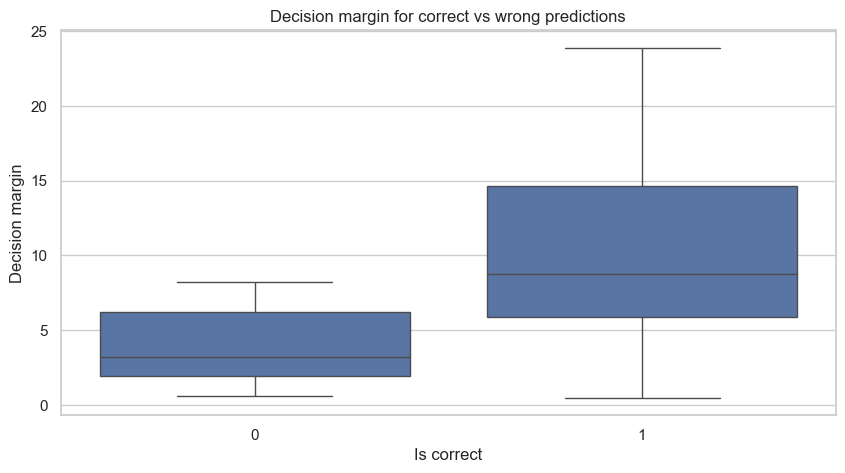

,count,mean,std,min,25%,50%,75%,max
is_correct,,,,,,,,
0,5.0,4.031171,3.130234,0.615766,1.922905,3.188843,6.186752,8.241590
1,46.0,10.197268,6.632320,0.479399,5.873228,8.736028,14.669671,23.889418


In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=error_analysis_df, x="is_correct", y="decision_margin")
plt.title("Decision margin for correct vs wrong predictions")
plt.xlabel("Is correct")
plt.ylabel("Decision margin")
plt.show()
display(error_analysis_df.groupby("is_correct")["decision_margin"].describe())

In [31]:
error_summary_df = pd.DataFrame({
    "metric": [
        "test_rows",
        "correct_predictions",
        "wrong_predictions",
        "error_rate"
    ],
    "value": [
        len(error_analysis_df),
        (error_analysis_df["is_correct"] == 1).sum(),
        (error_analysis_df["is_correct"] == 0).sum(),
        (error_analysis_df["is_correct"] == 0).mean()
    ]
})

display(error_summary_df)

,metric,value
0,test_rows,51.000000
1,correct_predictions,46.000000
2,wrong_predictions,5.000000
3,error_rate,0.098039


## Итоги анализа ошибок

В рамках данного этапа был проведен детальный анализ ошибок лучшей модели `SGDClassifier_hinge` с использованием признака `Supplier_Name`.

### Основные наблюдения
1. Модель демонстрирует высокое общее качество, однако ошибки сохраняются для части редких или семантически близких классов.
2. Наиболее частые ошибки возникают между классами, которые имеют близкие по смыслу описания документов, пересекаются по видам услуг или связаны с похожими поставщиками.
3. Признак `Supplier_Name` действительно повышает качество модели, но часть предсказаний может опираться на устойчивые связи между поставщиком и бухгалтерским счетом.
4. Анализ `decision_margin` позволяет оценить уверенность модели: меньшие значения margin характерны для более неоднозначных объектов.
5. Ошибки модели полезно интерпретировать не только количественно, но и содержательно — через анализ текста документа, поставщика и вида деятельности.

### Вывод
Выбранная модель показывает сильный результат и может рассматриваться как основное решение задачи. При этом анализ ошибок показывает, что качество можно дополнительно улучшать за счет более тонкой настройки текстовых признаков, более глубокого анализа неоднозначных документов и осторожного обращения с сущностными признаками.